In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
import h5py

from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

from utility.contour_scatter_plot import contour_scatter_plot
from pipeline.processing.fit_continuum import _powerlaw
from pipeline.processing.fit_gaussians import _gaussian, _two_gaussian
from pipeline.processing.measure_line import lam_to_vel
from pipeline.processing.parameters import CIV_AIR, NV_AIR, LYA_AIR, CIV_FIT_WINDOW, LYA_NV_FIT_WINDOW

FIT_PARAMS_PATH = "data/fit_params.csv"
RELEVANT_RESULTS_PATH = "data/relevant_results.csv"
SPECTRA_PATH = "data/spectra.h5"
CIV_BLUESHIFT_PATH = "data/civ_blueshift_vals.csv"


settings = {
        'font.size':16,
        'xtick.direction':'in', 
#         # 'xtick.minor.visible':True,
#         # 'xtick.top':True,
        'ytick.direction':'in', 
#         # 'ytick.minor.visible':True,
#         # 'ytick.right':True,
#         # 'xtick.major.size':4.0,
#         # 'xtick.minor.size':2.0,
#         # 'ytick.major.size':4.0,
#         # 'ytick.minor.size':2.0,
        'legend.frameon':False,
        # 'mathtext.fontset':'stix',
        # 'font.family':'STIXGeneral'
    }

plt.rcParams.update(**settings)

In [6]:
results = pd.read_csv(RELEVANT_RESULTS_PATH,index_col=0,dtype={"targetid":"str"})
fit_params = pd.read_csv(FIT_PARAMS_PATH,index_col=0,dtype={"targetid":"str"})
fit_params = fit_params[fit_params.index.isin(results.index)].copy()

In [7]:
# with h5py.File(SPECTRA_PATH, "r") as f:
#     test_idxs = list(f.keys())

In [8]:
# targetid = str(108023171252224)

# with h5py.File(SPECTRA_PATH, "r") as f:
#     data = f[f"{targetid}"][()]

#     lam = data[0,:]
#     # flux = data[1,:]

#### Luminosity calculation

In [9]:
cosmo = FlatLambdaCDM(H0=71,Om0=0.27)

In [10]:
def luminosity1450(targetid,cosmo,result_df,fit_param_df,ref_lam=1450.0):
    '''Calculates λL_λ(1450) for a given targetid.'''
    
    cont_params = ast.literal_eval(fit_param_df.loc[targetid,"continuum_fit_lya_nv"])["fit_params"]

    flux_1450A = _powerlaw(1450/1290,**cont_params)
    z = result_df.loc[targetid,"z"]

    luminosity_distance_cm = cosmo.luminosity_distance(z).to(u.cm).value

    return (luminosity_distance_cm**2) * 4 * np.pi * flux_1450A * 1450 *10E-17


In [11]:
results_copy = results.copy().reset_index()

In [12]:
results_copy["luminosity_1450A"] = results_copy["targetid"].apply(lambda x: luminosity1450(x,cosmo=cosmo,result_df=results,fit_param_df=fit_params))

In [13]:
results_copy = results_copy[results_copy["targetid"]!="39627636372146550"].copy()

In [14]:
results_copy["luminosity_1450A_log"] = np.log10(results_copy["luminosity_1450A"])
results_copy["rew_civ_log"] = np.log10(results_copy["rew_civ"])

/home/leya/miniconda3/envs/BA/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/leya/miniconda3/envs/BA/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


##### scatter plots

<Axes: xlabel='luminosity_1450A_log', ylabel='rew_civ_log'>

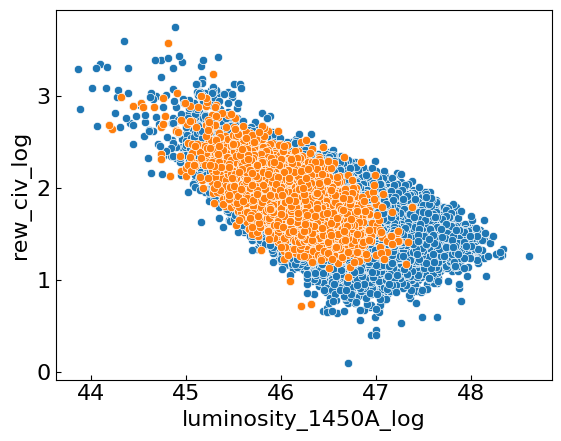

In [15]:
sns.scatterplot(data=results_copy,x="luminosity_1450A_log",y="rew_civ_log")
sns.scatterplot(data=results_copy[(results_copy["z-w3"]>3.9) & (results_copy["z"]>2) & (results_copy["z"]<3.4) & (results_copy["snr_w3"]>3)],x="luminosity_1450A_log",y="rew_civ_log")
# plt.xscale("log")
# plt.yscale("log")

<Axes: xlabel='luminosity_1450A_log', ylabel='rew_civ_log'>

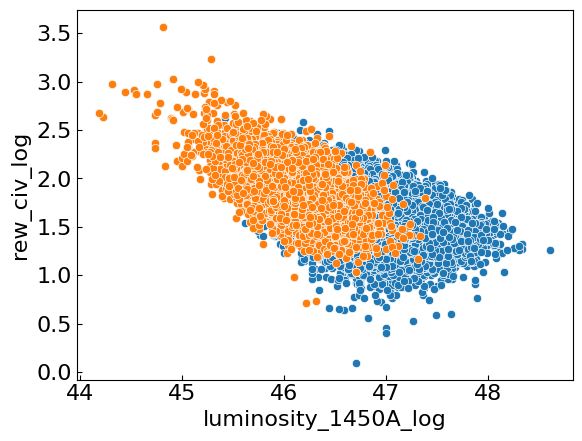

In [16]:
sns.scatterplot(data=results_copy[(results_copy["snr_w3"]>3)],x="luminosity_1450A_log",y="rew_civ_log")
sns.scatterplot(data=results_copy[(results_copy["z-w3"]>3.9) & (results_copy["z"]>2) & (results_copy["z"]<3.4) & (results_copy["snr_w3"]>3)],x="luminosity_1450A_log",y="rew_civ_log")
# plt.xscale("log")
# plt.yscale("log")

##### contour scatter plot

In [18]:
plot_df = results_copy[(results_copy["rew_civ_log"].notna()) & np.isfinite(results_copy["rew_civ_log"]) & (results_copy["luminosity_1450A_log"].notna()) & np.isfinite(results_copy["luminosity_1450A_log"]) & (results_copy["z"]>2) & (results_copy["z"]<3.4)]

# contour_scatter_plot(plot_df.head(100),x="luminosity_1450A_log",y="rew_civ_log",subsample_col=None,y_threshold=None)

[]

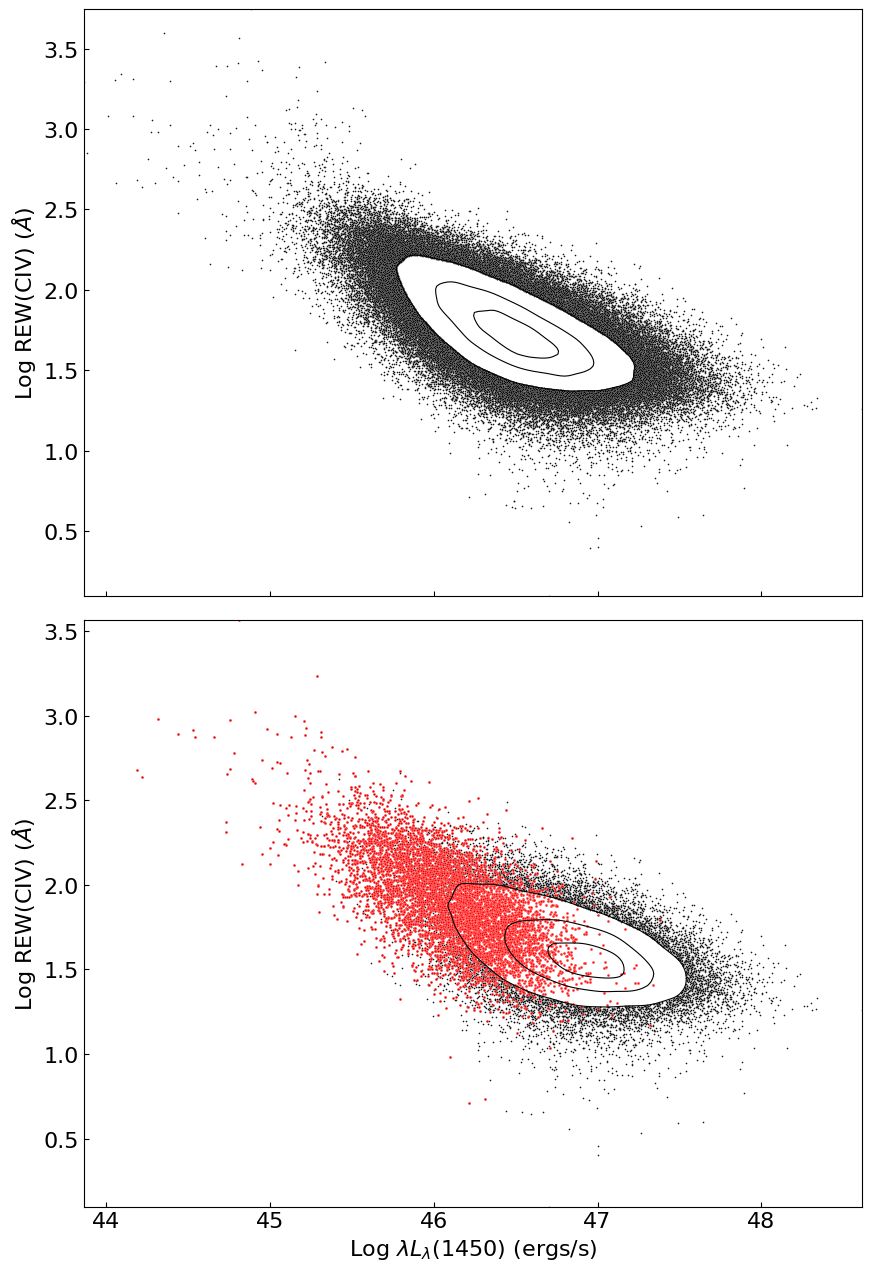

In [22]:
fig, axes = plt.subplots(2,1,figsize=(9,13),sharex=True)

contour_scatter_plot(plot_df,x="luminosity_1450A_log",y="rew_civ_log",subsample_col=None,y_threshold=None,ax=axes[0],x_label=r"Log $\lambda L_{\lambda}(1450)$ (ergs/s)",y_label=r"Log REW(CIV) ($\AA$)")

contour_scatter_plot(plot_df[(plot_df["flux_w3"].notna()) & (plot_df["snr_w3"]>3)],x="luminosity_1450A_log",y="rew_civ_log",subsample_col="z-w3",subsample_cutoff=3.9,y_threshold=None,ax=axes[1],x_label=r"Log $\lambda L_{\lambda}(1450)$ (ergs/s)",y_label=r"Log REW(CIV) ($\AA$)")

plt.tight_layout()

plt.savefig("images/baldwin-plot.png")

plt.plot()

#### CIV blueshift

In [3]:
lam_civ = np.arange(*CIV_FIT_WINDOW,0.1)
lam_lya = np.arange(*LYA_NV_FIT_WINDOW,0.1)

In [35]:
from pipeline.processing.remove_spikes import remove_spikes

In [69]:
for idx in results.index:
    # civ_params = ast.literal_eval(fit_params.loc[idx,"line_fit_civ"])["fit_params"]
    # lya_params = ast.literal_eval(fit_params.loc[idx,"line_fit_lya"])["fit_params"]

    # civ_profile = _gaussian(lam_civ,**civ_params) if len(civ_params)==3 else _two_gaussian(lam_civ,**civ_params)
    # lya_profile = _gaussian(lam_lya,**lya_params) if len(lya_params)==3 else _two_gaussian(lam_lya,**lya_params)
    # # cen_c=civ_params["cen_c"],cen_w=civ_params["cen_w"],amp_c=civ_params["amp_c"],amp_w=civ_params["amp_w"],sigma_c=civ_params["sigma_c"],sigma_w=civ_params["sigma_w"]

    # civ_peak = lam_civ[np.argmax(civ_profile)]
    # lya_peak = lam_lya[np.argmax(lya_profile)]

    if pd.isna(results.loc[idx,"lya_shift_vel_raw"]):
    
        with h5py.File(SPECTRA_PATH, "r") as f:
            data = f[f"{idx}"][()]

            lam = data[0,:]
            flux = data[1,:]
            ivar = data[2,:]

        flux_clean, _ = remove_spikes(lam=lam,flux=flux,ivar=ivar)

        civ_mask = (lam > CIV_FIT_WINDOW[0]) & (lam < CIV_FIT_WINDOW[1])
        lya_mask = (lam > LYA_NV_FIT_WINDOW[0]) & (lam < NV_AIR) 

        civ_peak = lam[civ_mask][np.argmax(flux_clean[civ_mask])]
        lya_peak = lam[lya_mask][np.argmax(flux_clean[lya_mask])]

        # fit_params.loc[idx,"civ_shift_vel"] = lam_to_vel(civ_peak,lam0=CIV_AIR)
        # fit_params.loc[idx,"lya_shift_vel"] = lam_to_vel(lya_peak,lam0=LYA_AIR)
        results.loc[idx,"civ_shift_vel_raw"] = lam_to_vel(civ_peak,lam0=CIV_AIR)
        results.loc[idx,"lya_shift_vel_raw"] = lam_to_vel(lya_peak,lam0=LYA_AIR)

In [79]:
# results[["civ_shift_vel_raw","lya_shift_vel_raw","shift_diff"]].to_csv(CIV_BLUESHIFT_PATH)

shifts = pd.read_csv(CIV_BLUESHIFT_PATH,index_col=0,dtype={"targetid":"str"})

##### full

In [70]:
# fit_params["shift_diff"] = fit_params["civ_shift_vel"] - fit_params["lya_shift_vel"]
results["shift_diff"] = results["civ_shift_vel_raw"] - results["lya_shift_vel_raw"]

full_idxs = results[(results["z"]>2) & (results["z"]<3.4)].index

# fit_params[fit_params.index.isin(full_idxs)][["civ_shift_vel","lya_shift_vel","shift_diff"]].describe()
results[results.index.isin(full_idxs)][["civ_shift_vel_raw","lya_shift_vel_raw","shift_diff"]].describe()

,civ_shift_vel_raw,lya_shift_vel_raw,shift_diff
count,177446.000000,177446.000000,177446.000000
mean,-172.133947,173.606420,-345.740367
std,1134.648793,1024.100987,1499.391162
min,-9491.065311,-16104.663352,-14666.650153
25%,-491.033871,-24.578649,-666.115225
50%,-96.377929,196.502424,-242.628627
75%,192.270431,380.443691,88.797067
max,9856.910724,6034.099481,18397.462560


##### W3 detected

In [71]:
w3_detected_idxs = results[(results["z"]>2) & (results["z"]<3.4) & (results["snr_w3"]>3)].index

# fit_params[fit_params.index.isin(w3_detected_idxs)][["civ_shift_vel","lya_shift_vel","shift_diff"]].describe()
results[results.index.isin(w3_detected_idxs)][["civ_shift_vel_raw","lya_shift_vel_raw","shift_diff"]].describe()

,civ_shift_vel_raw,lya_shift_vel_raw,shift_diff
count,43619.000000,43619.000000,43619.000000
mean,-310.639488,287.961682,-598.601170
std,1063.398556,1105.068434,1501.373141
min,-9487.307588,-16070.556799,-14495.249347
25%,-680.783788,-44.026624,-976.144906
50%,-191.327100,234.903433,-356.243182
75%,128.412031,505.811911,7.680092
max,9856.910724,6034.099481,17113.948880


##### ERQ

In [72]:
erq_idxs = results[(results["z-w3"]>3.9) & (results["z"]>2) & (results["z"]<3.4) & (results["snr_w3"]>3)].index

# fit_params[fit_params.index.isin(erq_idxs)][["civ_shift_vel","lya_shift_vel","shift_diff"]].describe()
results[results.index.isin(erq_idxs)][["civ_shift_vel_raw","lya_shift_vel_raw","shift_diff"]].describe()

,civ_shift_vel_raw,lya_shift_vel_raw,shift_diff
count,6376.000000,6376.000000,6376.000000
mean,-100.565609,343.467597,-444.033206
std,1127.584828,1599.798749,1982.165823
min,-9307.953091,-15692.302415,-13902.387300
25%,-356.632188,8.664694,-598.625543
50%,-48.361281,192.140951,-207.222966
75%,207.108005,367.924179,113.872080
max,9724.825825,6033.977315,16477.648218


##### core ERQ

In [ ]:
core_erq_idxs = results[(results["rew_civ"]>100) & (results["z-w3"]>3.9) & (results["z"]>2) & (results["z"]<3.4) & (results["snr_w3"]>3)].index

# fit_params[fit_params.index.isin(core_erq_idxs)][["civ_shift_vel","lya_shift_vel","shift_diff"]].describe()
results[results.index.isin(core_erq_idxs)][["civ_shift_vel_raw","lya_shift_vel_raw","shift_diff"]].describe()

,civ_shift_vel_raw,lya_shift_vel_raw,shift_diff
count,2141.000000,2141.000000,2141.000000
mean,-60.695450,306.950718,-367.646168
std,942.725305,1794.491412,2069.059117
min,-8342.196270,-15692.302415,-10599.722707
25%,-283.554870,-21.697346,-469.112981
50%,-25.553932,164.546541,-165.112189
75%,196.890951,309.172158,119.330384
max,9724.825825,6028.515659,16477.648218


#### basic stats

In [34]:
w3_color_med = results[(results["z"]>2) & (results["z"]<3.4) & (results["snr_w3"]>3)]["z-w3"].median()
w3_color_std = results[(results["z"]>2) & (results["z"]<3.4) & (results["snr_w3"]>3)]["z-w3"].std()

core_erq_color_med = results[(results["rew_civ"]>100) & (results["z-w3"]>3.9) & (results["z"]>2) & (results["z"]<3.4) & (results["snr_w3"]>3)]["z-w3"].median()
core_erq_color_std = results[(results["rew_civ"]>100) & (results["z-w3"]>3.9) & (results["z"]>2) & (results["z"]<3.4) & (results["snr_w3"]>3)]["z-w3"].std()

core_erq_redshift_med = results[(results["rew_civ"]>100) & (results["z-w3"]>3.9) & (results["z"]>2) & (results["z"]<3.4) & (results["snr_w3"]>3)]["z"].median()
core_erq_redshift_std = results[(results["rew_civ"]>100) & (results["z-w3"]>3.9) & (results["z"]>2) & (results["z"]<3.4) & (results["snr_w3"]>3)]["z"].std()

print(f"W3 detected sample:\nmedian z-W3\t= {w3_color_med:.2f} +-{w3_color_std:.2f}\n\nCore ERQ:\nmedian z-W3\t= {core_erq_color_med:.2f} +-{core_erq_color_std:.2f}\nmedian redshift\t= {core_erq_redshift_med:.2f} +-{core_erq_redshift_std:.2f}")

W3 detected sample:
median z-W3	= 2.79 +-0.92

Core ERQ:
median z-W3	= 4.81 +-0.83
median redshift	= 2.48 +-0.29
